In [ ]:
# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================
# Mount Drive so the zipped dataset can be read directly.
# Avoids re-uploading every time the Colab session restarts.

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# UNZIP DATASET
# ============================================================
# The .jsonl files are inside a zip on Drive. Extract to /content/
# so HuggingFace `datasets` can load them as normal local files.
# File sizes printed for a quick sanity check.

import zipfile
import os

zip_path   = '/content/drive/MyDrive/coursework_task02_reviews.zip'
extract_to = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Extraction complete. Files extracted:")
for f in os.listdir(extract_to):
    if f.endswith('.jsonl'):
        size_mb = os.path.getsize(os.path.join(extract_to, f)) / (1024 ** 2)
        print(f"  {f} ({size_mb:.2f} MB)")

Extraction complete. Files extracted:
  reviews_1g_test.jsonl (102.70 MB)
  reviews_1g_train.jsonl (920.20 MB)


In [ ]:
# ============================================================
# INSTALL DEPENDENCIES
# ============================================================
# accelerate is needed for some HuggingFace utilities.
# sentencepiece is required by the FLAN-T5 tokenizer used later.

!pip install transformers==4.41.2 datasets accelerate sentencepiece --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 87.6 MB/s eta 0:00:00


In [ ]:
# ============================================================
# IMPORTS
# ============================================================

# Core ML and numerical stack
import tensorflow as tf
import numpy as np
import random

# Plotting and visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset handling (HuggingFace)
from datasets import load_dataset

# Metrics and evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    f1_score,
)

# Models and tokenizers (Transformers)
from transformers import (
    AutoTokenizer,
    TFAutoModelForSequenceClassification,
    pipeline,
    TFAutoModelForSeq2SeqLM,
)

# Progress bar for prediction loops
from tqdm import tqdm

# Utility
from collections import Counter

# Seeds for reproducibility.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
# ============================================================
# LOAD DATASET
# ============================================================
# Both splits load as plain JSON Lines. The HuggingFace loader
# treats every file as having a "train" split internally, even
# for the test file, which is why both calls use split="train".

TRAIN_PATH = "/content/reviews_1g_train.jsonl"
TEST_PATH  = "/content/reviews_1g_test.jsonl"

# Sanity check both files are present before loading.
assert os.path.exists(TRAIN_PATH), f"Training file not found: {TRAIN_PATH}"
assert os.path.exists(TEST_PATH),  f"Test file not found: {TEST_PATH}"

train_data = load_dataset("json", data_files=TRAIN_PATH, split="train")
test_data  = load_dataset("json", data_files=TEST_PATH,  split="train")

print(f"Raw train size: {len(train_data):,}")
print(f"Raw test size:  {len(test_data):,}")

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Raw train size: 1,516,680
Raw test size:  168,931


In [ ]:
# ============================================================
# MAP STARS TO SENTIMENT CLASSES
# ============================================================
# Collapse the 5-point star scale into 3 sentiment buckets:
#     0 = negative  (1-2 stars)
#     1 = neutral   (3 stars)
#     2 = positive  (4-5 stars)
# This makes a 3 class problem with realistic imbalance, since
# positive ratings dominate review datasets.

def map_label(example):
    """Add an integer sentiment label based on the star rating."""
    stars = example["stars"]
    if stars <= 2:
        example["label"] = 0       # negative
    elif stars == 3:
        example["label"] = 1       # neutral
    else:
        example["label"] = 2       # positive
    return example

train_data = train_data.map(map_label)
test_data  = test_data.map(map_label)

# Bidirectional mappings for readable output later.
label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}

Map:   0%|          | 0/1516680 [00:00<?, ? examples/s]

Map:   0%|          | 0/168931 [00:00<?, ? examples/s]

In [ ]:
# ============================================================
# CHECK CLASS DISTRIBUTION
# ============================================================
# Verify the imbalance and decide if it justifies macro F1
# rather than weighted F1 as the headline metric.

def print_distribution(name, data):
    counts = Counter(data["label"])
    total = sum(counts.values())
    print(f"\n{name} ({total:,} examples):")
    for label_id in sorted(counts.keys()):
        label_name = id2label[label_id]
        count = counts[label_id]
        pct = (count / total) * 100
        print(f"  {label_name:9s}  {count:>7,}  ({pct:5.1f}%)")

print_distribution("Train", train_data)
print_distribution("Test",  test_data)


Train (1,516,680 examples):
  negative   349,405  ( 23.0%)
  neutral    149,738  (  9.9%)
  positive   1,017,537  ( 67.1%)

Test (168,931 examples):
  negative    38,844  ( 23.0%)
  neutral     16,855  ( 10.0%)
  positive   113,232  ( 67.0%)


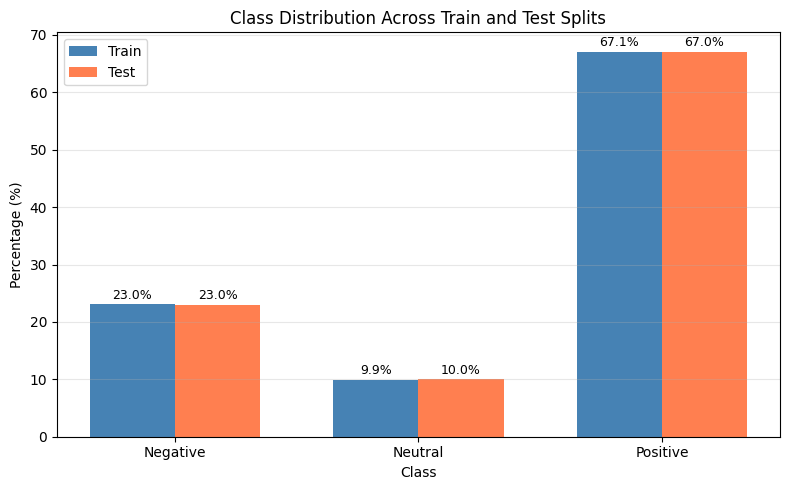

In [ ]:
# ============================================================
# PLOT CLASS DISTRIBUTIONS
# ============================================================
# Visualise the class proportions side by side. Confirms the
# imbalance is consistent across both splits, which means the
# test set is a fair benchmark for models trained on the train
# set rather than artificially easier or harder.

train_counts = Counter(train_data["label"])
test_counts = Counter(test_data["label"])

train_total = sum(train_counts.values())
test_total = sum(test_counts.values())

labels = ["Negative", "Neutral", "Positive"]
train_pcts = [train_counts[i] / train_total * 100 for i in range(3)]
test_pcts  = [test_counts[i]  / test_total  * 100 for i in range(3)]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, train_pcts, width, label='Train', color='steelblue')
bars2 = ax.bar(x + width/2, test_pcts,  width, label='Test',  color='coral')

ax.set_xlabel('Class')
ax.set_ylabel('Percentage (%)')
ax.set_title('Class Distribution Across Train and Test Splits')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Value labels on top of each bar so percentages are readable
# without squinting at the y axis.
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figure_7_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# CREATE SUBSETS FOR FASTER TRAINING AND EVALUATION
# ============================================================
# Fine tuning on the full ~1M training examples is impractical
# in a Colab session. A 100,000 example shuffled subset is used
# for training. Random sampling at this size approximately
# preserves the 67/23/10 class proportions without explicit
# stratification.
#
# A 5,000 example test subset is used for evaluation across all
# three approaches, allowing direct comparison on identical data.

TRAIN_SUBSET_SIZE = 100_000
TEST_SUBSET_SIZE  = 5_000

small_train = train_data.shuffle(seed=SEED).select(range(TRAIN_SUBSET_SIZE))
small_test  = test_data.shuffle(seed=SEED).select(range(TEST_SUBSET_SIZE))

print(f"Subset train distribution: {dict(Counter(small_train['label']))}")
print(f"Subset test  distribution: {dict(Counter(small_test['label']))}")

Subset train distribution: {0: 22955, 2: 67115, 1: 9930}
Subset test  distribution: {0: 1192, 2: 3315, 1: 493}


In [ ]:
# ============================================================
# TOKENISE FOR BERT-TINY
# ============================================================
# BERT-tiny uses the standard BERT WordPiece tokeniser. Sequences
# longer than 128 tokens are truncated. This is shorter than BERT's
# full 512 token capacity but enough to capture sentiment in most
# reviews and trains substantially faster.

tokenizer = AutoTokenizer.from_pretrained("prajjwal1/bert-tiny")

def tokenize_batch(batch):
    """Tokenise a batch of review texts with fixed length padding."""
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128,
    )

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
# ============================================================
# APPLY TOKENISATION
# ============================================================
# Tokenise both subsets in batched mode for speed. Adds
# `input_ids` and `attention_mask` columns to each example.

small_train = small_train.map(tokenize_batch, batched=True)
small_test  = small_test.map(tokenize_batch,  batched=True)

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [ ]:
# ============================================================
# CONVERT TO TENSORFLOW DATASETS
# ============================================================
# `to_tf_dataset` wraps the HuggingFace dataset in a tf.data
# pipeline so it can be passed straight to model.fit().
# Batch size 64 fits comfortably on a Colab T4.

train_tf = small_train.to_tf_dataset(
    columns=["input_ids", "attention_mask"],
    label_cols=["label"],
    shuffle=True,
    batch_size=64,
)

test_tf = small_test.to_tf_dataset(
    columns=["input_ids", "attention_mask"],
    label_cols=["label"],
    shuffle=False,
    batch_size=64,
)

/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


In [ ]:
# ============================================================
# COMPUTE CLASS WEIGHTS
# ============================================================
# Reviews are heavily skewed toward positive, which means a model
# can score high accuracy by ignoring the neutral class entirely.
# Inverse frequency weights penalise mistakes on rare classes
# more heavily, pushing the model to learn neutral despite its
# scarcity.

label_counts = Counter(small_train["label"])
total        = sum(label_counts.values())
num_classes  = len(label_counts)

class_weight = {
    cls: total / (num_classes * count)
    for cls, count in label_counts.items()
}

print("Class weights (inverse frequency):")
for cls in sorted(class_weight):
    print(f"  {id2label[cls]:9s}  weight = {class_weight[cls]:.3f}  (n = {label_counts[cls]:,})")

Class weights (inverse frequency):
  negative   weight = 1.452  (n = 22,955)
  neutral    weight = 3.357  (n = 9,930)
  positive   weight = 0.497  (n = 67,115)


In [ ]:
# ============================================================
# LOAD AND COMPILE BERT-TINY
# ============================================================
# Load BERT-tiny with a classification head sized for 3 classes.
# Pretrained weights are kept; the classification head is initialised
# randomly and trained from scratch during fine tuning.
#
# The model weights are stored as PyTorch files on Hugging Face,
# so from_pt=True converts them to TensorFlow at load time.

# Code adapted from: https://huggingface.co/docs/transformers/training

model = TFAutoModelForSequenceClassification.from_pretrained(
    "prajjwal1/bert-tiny",
    num_labels=3,
    from_pt=True,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

model.summary()

pytorch_model.bin:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertForSequenceClassification: ['bert.embeddings.position_ids']
- This IS expected if you are initializing TFBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: "tf_bert_for_sequence_classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bert (TFBertMainLayer)      multiple                  4385920   
                                                                 
 dropout_7 (Dropout)         multiple                  0         
                                                                 
 classifier (Dense)          multiple                  387       
                                                                 
Total params: 4386307 (16.73 MB)
Trainable params: 4386307 (16.73 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# ============================================================
# TRAIN BERT-TINY
# ============================================================
# Up to 8 epochs with early stopping. One epoch is not enough
# for BERT-tiny to converge, while 8 leaves headroom for early
# stopping to halt before overfitting. Patience of 2 means
# training stops if validation loss fails to improve for two
# consecutive epochs.

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

history = model.fit(
    train_tf,
    validation_data=test_tf,
    epochs=8,
    class_weight=class_weight,
    callbacks=[early_stop],
)

Epoch 1/8
1563/1563 [==============================] - 140s 70ms/step - loss: 0.8098 - accuracy: 0.6981 - val_loss: 0.5685 - val_accuracy: 0.7684
Epoch 2/8
1563/1563 [==============================] - 61s 39ms/step - loss: 0.6327 - accuracy: 0.7604 - val_loss: 0.5255 - val_accuracy: 0.7744
Epoch 3/8
1563/1563 [==============================] - 59s 38ms/step - loss: 0.5911 - accuracy: 0.7744 - val_loss: 0.4967 - val_accuracy: 0.7890
Epoch 4/8
1563/1563 [==============================] - 59s 38ms/step - loss: 0.5647 - accuracy: 0.7862 - val_loss: 0.4957 - val_accuracy: 0.7886
Epoch 5/8
1563/1563 [==============================] - 59s 38ms/step - loss: 0.5404 - accuracy: 0.7958 - val_loss: 0.4763 - val_accuracy: 0.7994
Epoch 6/8
1563/1563 [==============================] - 60s 38ms/step - loss: 0.5205 - accuracy: 0.8033 - val_loss: 0.4893 - val_accuracy: 0.7920
Epoch 7/8
1563/1563 [==============================] - 60s 38ms/step - loss: 0.5020 - accuracy: 0.8101 - val_loss: 0.4760 - val_a

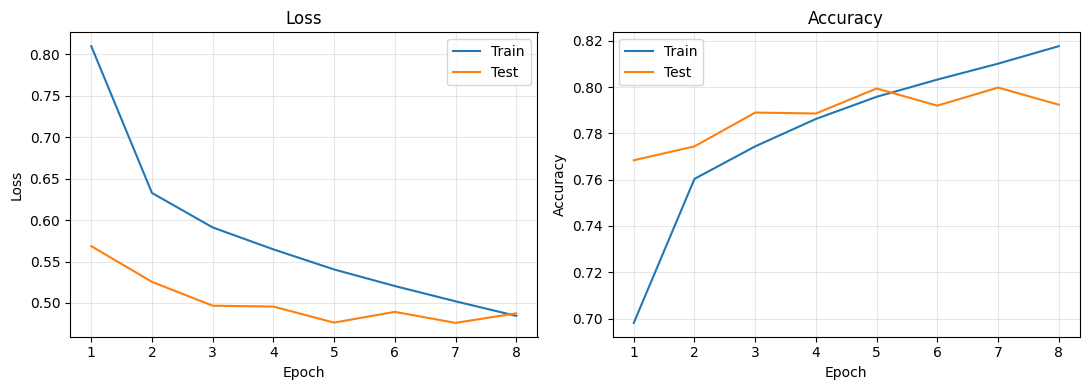

In [ ]:
# ============================================================
# PLOT TRAINING CURVES
# ============================================================
# Quick visual check that training behaved sensibly. Loss should
# decrease, accuracy should increase. Large gaps between train
# and held-out curves indicate overfitting.

epochs_range = range(1, len(history.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs_range, history.history["loss"],     label="Train")
axes[0].plot(epochs_range, history.history["val_loss"], label="Test")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history.history["accuracy"],     label="Train")
axes[1].plot(epochs_range, history.history["val_accuracy"], label="Test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SAVE TRAINED MODEL
# ============================================================
# Save model weights and tokenizer to Drive so the pipeline can
# be reloaded later without retraining. Defensive in case Colab
# disconnects.

BERT_SAVE_DIR = "/content/drive/MyDrive/Machine Learning/checkpoints/bert_tiny_trained"

model.save_pretrained(BERT_SAVE_DIR)
tokenizer.save_pretrained(BERT_SAVE_DIR)

print(f"BERT-tiny model and tokenizer saved to:")
print(f"  {BERT_SAVE_DIR}")

BERT-tiny model and tokenizer saved to:
  /content/drive/MyDrive/Machine Learning/checkpoints/bert_tiny_trained


In [ ]:
# ============================================================
# RELOAD FROM DRIVE (NOT NEEDED IN A SINGLE SESSION)
# ============================================================
# Kept here as documentation. Use this to reload the saved model
# in a fresh notebook session without retraining.

# model     = TFAutoModelForSequenceClassification.from_pretrained(BERT_SAVE_DIR)
# tokenizer = AutoTokenizer.from_pretrained(BERT_SAVE_DIR)

# print(f"BERT-tiny model and tokenizer reloaded from:")
# print(f"  {BERT_SAVE_DIR}")

Some layers from the model checkpoint at /content/drive/MyDrive/Machine Learning/checkpoints/bert_tiny_trained were not used when initializing TFBertForSequenceClassification: ['dropout_7']
- This IS expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at /content/drive/MyDrive/Machine Learning/checkpoints/bert_tiny_trained.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for prediction

BERT-tiny model and tokenizer reloaded from:
  /content/drive/MyDrive/Machine Learning/checkpoints/bert_tiny_trained


In [ ]:
# ============================================================
# GENERATE PREDICTIONS (BERT-TINY)
# ============================================================
# model.predict batches internally, so the whole tf.data pipeline
# can be passed in one call rather than looping over batches by hand.

logits_all = model.predict(test_tf, verbose=1).logits
y_pred = np.argmax(logits_all, axis=1)

# Recover true labels in the same order. test_tf was created with
# shuffle=False, so iterating gives a stable order matching the
# prediction array above.
y_true = np.concatenate([labels.numpy() for _, labels in test_tf])

79/79 [==============================] - 2s 15ms/step


In [ ]:
# ============================================================
# EVALUATION METRICS (BERT-TINY)
# ============================================================
# Both macro and weighted averages are reported because of the
# class imbalance:
#   weighted F1 reflects overall performance (dominated by positive)
#   macro F1 weights each class equally, surfacing poor performance
#   on the rare neutral class

accuracy = accuracy_score(y_true, y_pred)
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")

print(f"Accuracy:           {accuracy:.4f}")
print(f"Weighted Precision: {prec_w:.4f}")
print(f"Weighted Recall:    {rec_w:.4f}")
print(f"Weighted F1:        {f1_w:.4f}")
print(f"Macro Precision:    {prec_m:.4f}")
print(f"Macro Recall:       {rec_m:.4f}")
print(f"Macro F1:           {f1_m:.4f}")

print("\nPer-class breakdown:")
print(classification_report(
    y_true, y_pred,
    target_names=list(id2label.values()),
    digits=4,
))

Accuracy:           0.7998
Weighted Precision: 0.8739
Weighted Recall:    0.7998
Weighted F1:        0.8260
Macro Precision:    0.7150
Macro Recall:       0.7586
Macro F1:           0.7104

Per-class breakdown:
              precision    recall  f1-score   support

    negative     0.8777    0.7584    0.8137      1192
     neutral     0.3109    0.6856    0.4278       493
    positive     0.9563    0.8317    0.8896      3315

    accuracy                         0.7998      5000
   macro avg     0.7150    0.7586    0.7104      5000
weighted avg     0.8739    0.7998    0.8260      5000



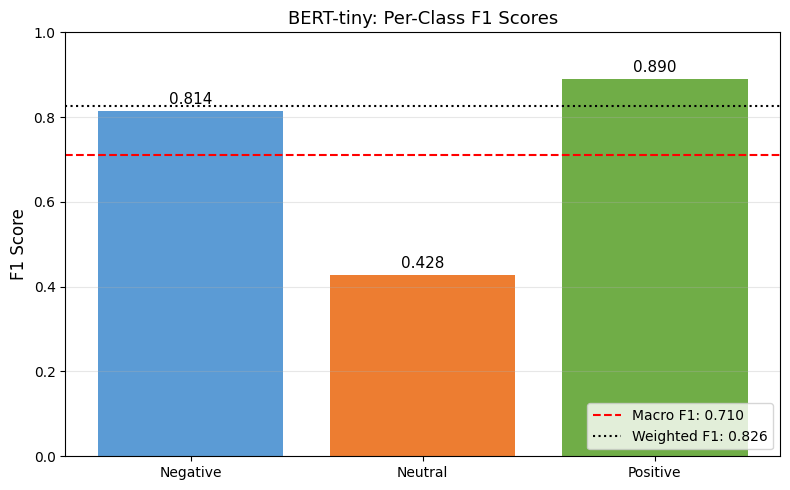

In [ ]:
# ============================================================
# PER-CLASS F1 CHART (BERT-TINY)
# ============================================================
# Visualise per class F1 scores to highlight the gap between the
# dominant positive class and the minority neutral class.

# Per class F1 scores
_, _, f1_per_class, _ = precision_recall_fscore_support(
    y_true, y_pred, average=None
)

labels = ["Negative", "Neutral", "Positive"]
colors = ["#5B9BD5", "#ED7D31", "#70AD47"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, f1_per_class, color=colors)

# Macro and weighted F1 reference lines so per class scores can
# be compared against both averages at a glance.
ax.axhline(y=f1_m, color='red', linestyle='--', linewidth=1.5,
           label=f'Macro F1: {f1_m:.3f}')
ax.axhline(y=f1_w, color='black', linestyle=':', linewidth=1.5,
           label=f'Weighted F1: {f1_w:.3f}')

# Value labels on each bar.
for bar, f1 in zip(bars, f1_per_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{f1:.3f}', ha='center', va='bottom', fontsize=11)

ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('BERT-tiny: Per-Class F1 Scores', fontsize=13)
ax.set_ylim(0, 1.0)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figure_9_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

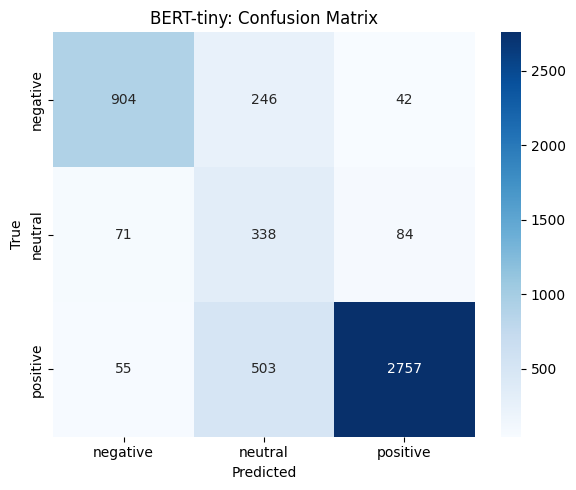

In [ ]:
# ============================================================
# CONFUSION MATRIX (BERT-TINY)
# ============================================================
# Shows where the model gets confused. A common pattern in 3 class
# sentiment is the neutral row leaking into positive, since mildly
# positive reviews look a lot like neutral ones.

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=id2label.values(),
    yticklabels=id2label.values(),
)
plt.title("BERT-tiny: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ERROR ANALYSIS BY ERROR TYPE (BERT-TINY)
# ============================================================
# Random misclassifications aren't very informative on their own.
# Grouping errors by (true, predicted) reveals which class
# confusions are most common, then example reviews from the
# largest error type can be inspected directly.

val_texts = small_test["text"]
errors_by_kind = {}

for i, (t, p) in enumerate(zip(y_true, y_pred)):
    if t != p:
        key = (id2label[int(t)], id2label[int(p)])
        errors_by_kind.setdefault(key, []).append(val_texts[i])

print("Misclassifications grouped by (true -> predicted):")
for key, examples in sorted(errors_by_kind.items(), key=lambda kv: -len(kv[1])):
    print(f"  {key[0]:>8}  ->  {key[1]:<8}  count = {len(examples)}")

# A few examples from the most common error type so the failure
# patterns described in the report can be traced back to specific
# reviews.
worst_key, worst_examples = max(errors_by_kind.items(), key=lambda kv: len(kv[1]))
print(f"\nExamples of the most common error type {worst_key}:\n")
for txt in worst_examples[:3]:
    print("-", txt[:300].replace("\n", " "), "...\n")

Misclassifications grouped by (true -> predicted):
  positive  ->  neutral   count = 503
  negative  ->  neutral   count = 246
   neutral  ->  positive  count = 84
   neutral  ->  negative  count = 71
  positive  ->  negative  count = 55
  negative  ->  positive  count = 42

Examples of the most common error type ('positive', 'neutral'):

- I've now been to the rathskeller twice, both times for a company Christmas party. Each time it has been a wonderful experience and I leave with the intention to visit during normal operation, so I'm going to make that my 2015 Yelp New Years resolution.   For now, I can only judge then based on cater ...

- Rolled into Tha Joint with twelve people and our first impression was...wow this place is a bit small and they weren't expecting a group as large as us but quicky jury rigged two tables together and hooked us up.  Of our group only 4 knew what we were doing and the others were kind of just going thr ...

- Like all In n Out's. Simple, clean,good f

In [ ]:
# ============================================================
# THRESHOLD TUNING ON NEUTRAL CLASS (BERT-TINY)
# ============================================================
# Error analysis showed BERT-tiny's neutral class has high recall
# (0.69) but low precision (0.31). The inverse frequency class
# weighting pushed the model to predict neutral too aggressively
# for anything ambiguous.
#
# A threshold rule is applied: predict neutral only if its softmax
# probability exceeds tau, otherwise pick whichever of negative or
# positive has the higher probability. Thresholds from 0.30 to 0.70
# are swept in 0.05 steps, selecting the value that maximises
# macro F1.
#
# Tuning on the same test set used for reporting is a methodological
# limitation, discussed in Section 2.5 of the report.

# Convert raw logits to softmax probabilities.
probs_all = tf.nn.softmax(logits_all, axis=1).numpy()

# Sweep neutral thresholds.
thresholds = np.arange(0.30, 0.71, 0.05)
sweep_results = []

for tau in thresholds:
    # Predict neutral only if P(neutral) >= tau, otherwise choose
    # whichever of negative or positive has the higher probability.
    preds_tuned = np.empty(len(probs_all), dtype=int)
    for i, p in enumerate(probs_all):
        if p[1] >= tau:
            preds_tuned[i] = 1
        else:
            preds_tuned[i] = 0 if p[0] > p[2] else 2

    acc = accuracy_score(y_true, preds_tuned)
    _, _, f1_w_t, _ = precision_recall_fscore_support(y_true, preds_tuned, average="weighted")
    _, _, f1_m_t, _ = precision_recall_fscore_support(y_true, preds_tuned, average="macro")
    _, _, f1_per_class_t, _ = precision_recall_fscore_support(y_true, preds_tuned, average=None)

    sweep_results.append({
        "tau": tau,
        "accuracy": acc,
        "weighted_f1": f1_w_t,
        "macro_f1": f1_m_t,
        "neg_f1": f1_per_class_t[0],
        "neu_f1": f1_per_class_t[1],
        "pos_f1": f1_per_class_t[2],
    })

# Print sweep results as a table.
print(f"{'tau':>6}{'acc':>10}{'weight F1':>12}{'macro F1':>12}{'neg F1':>10}{'neu F1':>10}{'pos F1':>10}")
print("-" * 70)
for r in sweep_results:
    print(f"{r['tau']:>6.2f}{r['accuracy']:>10.4f}{r['weighted_f1']:>12.4f}{

   tau       acc   weight F1    macro F1    neg F1    neu F1    pos F1
----------------------------------------------------------------------
  0.30    0.7444      0.7874      0.6723    0.7695    0.3952    0.8522
  0.35    0.7622      0.8000      0.6841    0.7830    0.4045    0.8649
  0.40    0.7800      0.8121      0.6972    0.7950    0.4199    0.8766
  0.45    0.7948      0.8223      0.7079    0.8082    0.4299    0.8857
  0.50    0.8056      0.8292      0.7135    0.8153    0.4319    0.8932
  0.55    0.8178      0.8365      0.7215    0.8212    0.4429    0.9005
  0.60    0.8246      0.8390      0.7207    0.8204    0.4361    0.9055
  0.65    0.8334      0.8428      0.7217    0.8248    0.4295    0.9107
  0.70    0.8404      0.8438      0.7135    0.8267    0.3973    0.9164

Best threshold: tau = 0.65
Macro F1 at best threshold: 0.7217
Improvement over default (argmax): 0.0113


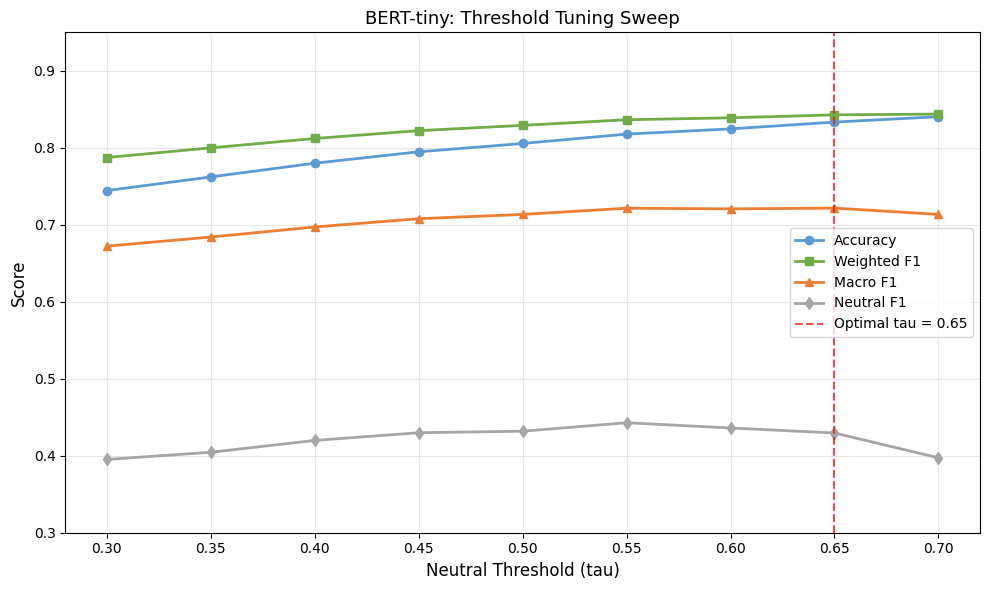

In [ ]:
# ============================================================
# THRESHOLD SWEEP CHART
# ============================================================
# Visualise how key metrics change as the neutral threshold
# varies from 0.30 to 0.70.

taus = [r['tau'] for r in sweep_results]
accuracies = [r['accuracy'] for r in sweep_results]
weighted_f1s = [r['weighted_f1'] for r in sweep_results]
macro_f1s = [r['macro_f1'] for r in sweep_results]
neutral_f1s = [r['neu_f1'] for r in sweep_results]

best_tau = max(sweep_results, key=lambda r: r['macro_f1'])['tau']

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(taus, accuracies, marker='o', linewidth=2, label='Accuracy', color='#5B9BD5')
ax.plot(taus, weighted_f1s, marker='s', linewidth=2, label='Weighted F1', color='#70AD47')
ax.plot(taus, macro_f1s, marker='^', linewidth=2, label='Macro F1', color='#ED7D31')
ax.plot(taus, neutral_f1s, marker='d', linewidth=2, label='Neutral F1', color='#A5A5A5')

ax.axvline(x=best_tau, color='red', linestyle='--', linewidth=1.5,
           alpha=0.7, label=f'Optimal tau = {best_tau:.2f}')

ax.set_xlabel('Neutral Threshold (tau)', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('BERT-tiny: Threshold Tuning Sweep', fontsize=13)
ax.set_xticks(taus)
ax.legend(loc='center right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.3, 0.95)

plt.tight_layout()
plt.show()

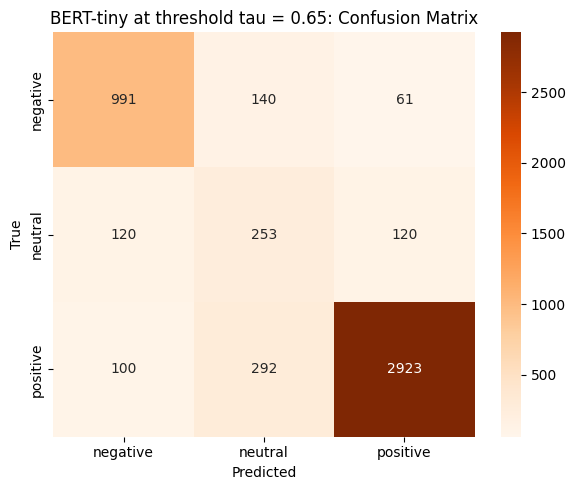


Per-class report at best threshold:
              precision    recall  f1-score   support

    negative     0.8183    0.8314    0.8248      1192
     neutral     0.3693    0.5132    0.4295       493
    positive     0.9417    0.8817    0.9107      3315

    accuracy                         0.8334      5000
   macro avg     0.7098    0.7421    0.7217      5000
weighted avg     0.8558    0.8334    0.8428      5000



In [ ]:
# ============================================================
# CONFUSION MATRIX AT BEST THRESHOLD
# ============================================================
# Reconstruct predictions at the best threshold and visualise
# the confusion matrix to see how the error pattern shifted
# compared to the default argmax matrix in the earlier cell.

best_tau = best["tau"]
preds_best = np.empty(len(probs_all), dtype=int)
for i, p in enumerate(probs_all):
    if p[1] >= best_tau:
        preds_best[i] = 1
    else:
        preds_best[i] = 0 if p[0] > p[2] else 2

cm_best = confusion_matrix(y_true, preds_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_best, annot=True, fmt="d", cmap="Oranges",
    xticklabels=id2label.values(),
    yticklabels=id2label.values(),
)
plt.title(f"BERT-tiny at threshold tau = {best_tau:.2f}: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

print("\nPer-class report at best threshold:")
print(classification_report(
    y_true, preds_best,
    target_names=list(id2label.values()),
    digits=4,
))

In [ ]:
# ============================================================
# ZERO-SHOT CLASSIFICATION (BART-MNLI)
# ============================================================
# True zero shot: BART-MNLI has not been fine tuned on the review
# data. Each candidate label is expressed as a natural language
# hypothesis, and the model picks the hypothesis with the highest
# entailment score against the review text.
#
# This reformulates sentiment classification as natural language
# inference, which lets BART-MNLI use its MultiNLI training
# without any sentiment specific data.

# Code adapted from: https://huggingface.co/docs/transformers/main_classes/pipelines#zero-shot-classification

zero_shot = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0 if tf.config.list_physical_devices("GPU") else -1,
)

# Hypotheses are full sentences rather than bare class names.
# This is closer to BART-MNLI's NLI training distribution and
# gives clearer signal than single word labels.
candidate_labels = [
    "This review expresses a negative opinion.",
    "This review expresses a neutral or mixed opinion.",
    "This review expresses a positive opinion.",
]

label_to_id_zs = {
    candidate_labels[0]: 0,    # negative
    candidate_labels[1]: 1,    # neutral
    candidate_labels[2]: 2,    # positive
}

# First 5000 of the shuffled test set (the shuffle was seeded so
# the selection is reproducible). Reviews truncated to the first
# 1000 characters (~256 tokens) to fit BART's input limit.
zs_sample = small_test.select(range(5000))

y_true_zs, y_pred_zs = [], []
for ex in tqdm(zs_sample, desc="Zero-shot predictions"):
    out = zero_shot(ex["text"][:1000], candidate_labels)
    top_label = out["labels"][0]
    y_pred_zs.append(label_to_id_zs[top_label])
    y_true_zs.append(ex["label"])

acc_zs = accuracy_score(y_true_zs, y_pred_zs)
_, _, f1_zs_w, _ = precision_recall_fscore_support(y_true_zs, y_pred_zs, average="weighted")
_, _, f1_zs_m, _ = precision_recall_fscore_support(y_true_zs, y_pred_zs, average="macro")

print(f"Zero-shot Accuracy:    {acc_zs:.4f}")
print(f"Zero-shot Weighted F1: {f1_zs_w:.4f}")
print(f"Zero-shot Macro F1:    {f1_zs_m:.4f}")
print("\nPer-class breakdown:")
print(classification_report(
    y_true_zs, y_pred_zs,
    target_names=list(id2label.values()),
    digits=4,
))

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Zero-shot predictions: 100%|██████████| 5000/5000 [11:57<00:00,  6.97it/s]

Zero-shot Accuracy:    0.8688
Zero-shot Weighted F1: 0.8676
Zero-shot Macro F1:    0.7311

Per-class breakdown:
              precision    recall  f1-score   support

    negative     0.8065    0.9094    0.8549      1192
     neutral     0.4170    0.3773    0.3962       493
    positive     0.9576    0.9273    0.9422      3315

    accuracy                         0.8688      5000
   macro avg     0.7271    0.7380    0.7311      5000
weighted avg     0.8683    0.8688    0.8676      5000



In [ ]:
# ============# ============================================================
# ZERO-SHOT PROMPT SENSITIVITY (BART-MNLI)
# ============================================================
# Test how much the headline numbers depend on label wording.
# Three label phrasings are evaluated on the same 500 example
# subsample. Full 5k zero shot across three variants would take
# roughly 30 minutes, which is too much for an exploratory probe.
# 500 limits precision but is enough to demonstrate sensitivity
# to prompt design.

# Three label phrasing variants.
label_variants = {
    "Sentence (original)": [
        "This review expresses a negative opinion.",
        "This review expresses a neutral or mixed opinion.",
        "This review expresses a positive opinion.",
    ],
    "Single word": [
        "negative",
        "neutral",
        "positive",
    ],
    "Emotion-framed": [
        "The reviewer is unhappy with the experience.",
        "The reviewer feels indifferent or has mixed feelings.",
        "The reviewer is happy with the experience.",
    ],
}

# Same 1000 character truncation as the main zero shot run.
prompt_sweep_sample = small_test.select(range(500))
sweep_zs_results = {}

for name, candidate_labels in label_variants.items():
    label_to_id = {candidate_labels[i]: i for i in range(3)}

    y_pred_v, y_true_v = [], []
    for ex in tqdm(prompt_sweep_sample, desc=f"Variant: {name}"):
        out = zero_shot(ex["text"][:1000], candidate_labels)
        top_label = out["labels"][0]
        y_pred_v.append(label_to_id[top_label])
        y_true_v.append(ex["label"])

    acc_v = accuracy_score(y_true_v, y_pred_v)
    _, _, f1_w_v, _ = precision_recall_fscore_support(y_true_v, y_pred_v, average="weighted")
    _, _, f1_m_v, _ = precision_recall_fscore_support(y_true_v, y_pred_v, average="macro")
    _, _, f1_per_v, _ = precision_recall_fscore_support(y_true_v, y_pred_v, average=None)

    sweep_zs_results[name] = {
        "accuracy": acc_v,
        "weighted_f1": f1_w_v,
        "macro_f1": f1_m_v,
        "neg_f1": f1_per_v[0],
        "neu_f1": f1_per_v[1],
        "pos_f1": f1_per_v[2],
    }

# Comparison table for the three variants.
print(f"\n{'Variant':<24}{'Accuracy':>10}{'Weighted F1':>14}{'Macro F1':>12}{'Neutral F1':>12}")
print("-" * 72)
for name, r in sweep_zs_results.items():
    print(f"{name:<24}{r['accuracy']:>10.4f}{r['weighted_f1']:>14.4f}{r['macro_f1']:>12.4f}{r['neu_f1']:>12.4f}")

Variant: Emotion-framed: 100%|██████████| 500/500 [01:10<00:00,  7.11it/s]


Variant                   Accuracy   Weighted F1    Macro F1  Neutral F1
------------------------------------------------------------------------
Sentence (original)         0.8820        0.8785      0.7505      0.4494
Single word                 0.8520        0.8151      0.5935      0.0392
Emotion-framed              0.8580        0.8698      0.7575      0.4882


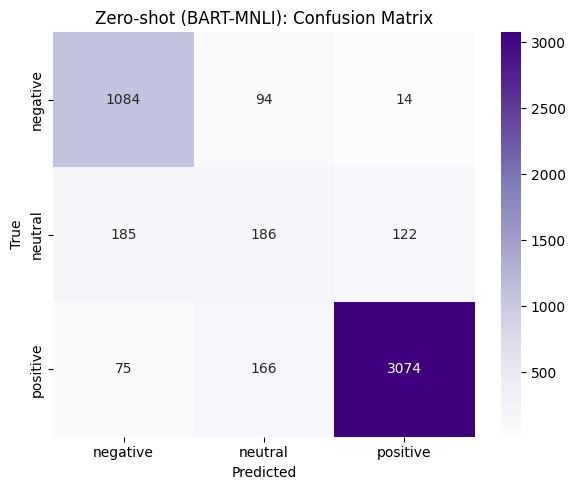

In [ ]:
# ============================================================
# ZERO-SHOT CONFUSION MATRIX
# ============================================================

cm_zs = confusion_matrix(y_true_zs, y_pred_zs)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_zs, annot=True, fmt="d", cmap="Purples",
    xticklabels=id2label.values(),
    yticklabels=id2label.values(),
)
plt.title("Zero-shot (BART-MNLI): Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# LOAD FLAN-T5
# ============================================================
# Instead of fine tuning, the task gets described in a prompt
# with a few labelled examples. FLAN-T5 continues the pattern
# and outputs a label as text. Few shot in context learning.
#
# Going with flan-t5-base because it's small enough for Colab,
# follows instructions reliably (it was instruction tuned), and
# being seq2seq makes the output easy to parse.

# Code adapted from: https://huggingface.co/docs/transformers/model_doc/t5

flan_tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
flan_model     = TFAutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base", from_pt=True)

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/tf_keras/src/initializers/initializers.py:121: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFT5ForConditionalGeneration: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight']
- This IS expected if you are initializing TFT5ForConditionalGeneration from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFT5ForConditionalGeneration from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassificati

In [ ]:
# ============================================================
# BUILD THE FEW-SHOT PROMPT
# ============================================================
# Two examples per class, six demonstrations total. Keeping the
# demonstrations balanced across classes matters here. If all six
# were positive, the model would just learn to say "positive".

def pick_examples_per_class(dataset, n_per_class=2, seed=SEED):
    """Sample n examples per class from the dataset.

    Collect a pool of up to 50 candidates per class, then randomly
    sample n_per_class from each pool. Avoids iterating the entire
    dataset while keeping the sample reproducible via the seed.
    """
    rng = random.Random(seed)
    by_class = {0: [], 1: [], 2: []}
    for ex in dataset:
        if len(by_class[ex["label"]]) < 50:
            by_class[ex["label"]].append(ex)
        if all(len(v) >= 50 for v in by_class.values()):
            break
    chosen = []
    for cls, pool in by_class.items():
        chosen.extend(rng.sample(pool, n_per_class))
    rng.shuffle(chosen)
    return chosen


few_shot_examples = pick_examples_per_class(train_data, n_per_class=2)


def format_prompt(text, examples):
    """Build a prompt with demonstrations followed by the query.

    Each demonstration and the final query truncate the review text
    to the first 200 characters so the full prompt with six
    demonstrations fits within FLAN-T5's input limit.
    """
    parts = [
        "Classify the sentiment of the review as 'negative', 'neutral', or 'positive'.\n"
    ]
    for ex in examples:
        parts.append(f"Review: {ex['text'][:200]}")
        parts.append(f"Sentiment: {id2label[ex['label']]}\n")
    parts.append(f"Review: {text[:200]}")
    parts.append("Sentiment:")
    return "\n".join(parts)

In [ ]:
# ============================================================
# RUN FEW-SHOT PREDICTIONS
# ============================================================
# Generation is slower than classification, so the same 5000
# example subsample as the zero shot run is used. The output
# text is searched for any of the three label words. If none is
# found, the prediction defaults to neutral as a safety net,
# though in practice this almost never triggers because FLAN-T5
# reliably emits one of the three labels.

def parse_label(text):
    """Map the model's generated text to a sentiment class id.

    Searches the output for any of the three label words. Returns
    the class id of the first match, or defaults to neutral (1) if
    the output does not contain a recognisable label.
    """
    text = text.strip().lower()
    for name, idx in label2id.items():
        if name in text:
            return idx
    return 1  # default to neutral if no label word is found

y_true_fs, y_pred_fs = [], []
for ex in tqdm(zs_sample, desc="Few-shot predictions"):
    prompt = format_prompt(ex["text"], few_shot_examples)
    inputs = flan_tokenizer(prompt, return_tensors="tf", truncation=True, max_length=512)
    out_ids = flan_model.generate(**inputs, max_new_tokens=5)
    out_text = flan_tokenizer.decode(out_ids[0], skip_special_tokens=True)
    y_pred_fs.append(parse_label(out_text))
    y_true_fs.append(ex["label"])

acc_fs = accuracy_score(y_true_fs, y_pred_fs)
_, _, f1_fs_w, _ = precision_recall_fscore_support(y_true_fs, y_pred_fs, average="weighted")
_, _, f1_fs_m, _ = precision_recall_fscore_support(y_true_fs, y_pred_fs, average="macro")

print(f"Few-shot Accuracy:    {acc_fs:.4f}")
print(f"Few-shot Weighted F1: {f1_fs_w:.4f}")
print(f"Few-shot Macro F1:    {f1_fs_m:.4f}")
print("\nPer-class breakdown:")
print(classification_report(
    y_true_fs, y_pred_fs,
    target_names=list(id2label.values()),
    digits=4,
))

Few-shot predictions: 100%|██████████| 5000/5000 [1:13:21<00:00,  1.14it/s]

Few-shot Accuracy:    0.8306
Few-shot Weighted F1: 0.7917
Few-shot Macro F1:    0.5635

Per-class breakdown:
              precision    recall  f1-score   support

    negative     0.6693    0.9203    0.7750      1192
     neutral     0.0000    0.0000    0.0000       493
    positive     0.9093    0.9219    0.9155      3315

    accuracy                         0.8306      5000
   macro avg     0.5262    0.6141    0.5635      5000
weighted avg     0.7624    0.8306    0.7917      5000




/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/

In [ ]:
# ============================================================
# PROMPT-SENSITIVITY PROBES (FLAN-T5)
# ============================================================
# FLAN-T5 never predicted neutral once across all 5,000 examples,
# producing F1 = 0.00 on that class. The probes below test whether
# this is a lexical bias against the word "neutral" or a structural
# bias toward binary outputs regardless of the labels used.
#
# Probe 1: relabel "neutral" as "mixed" in instruction and demos.
#          If the output is "mixed", the bias is lexical and a
#          relabel fixes it.
# Probe 2: replace labels with abstract numeric tokens (1/2/3).
#          If the output is "2", the bias is tied to sentiment
#          vocabulary rather than to the third class.
# Probe 3: oversample neutral in demos (4 neutral, 1 negative,
#          1 positive). If FLAN-T5 still never outputs neutral,
#          the prior cannot be overridden by demonstrations alone.
#
# Outputs stored as raw decoded strings rather than parsed class
# ids, so the model's actual behaviour stays visible in the counts.

# Probe 1: relabel neutral as "mixed".
def format_prompt_mixed(text, examples):
    label_map = {0: "negative", 1: "mixed", 2: "positive"}
    parts = [
        "Classify the sentiment of the review as 'negative', 'mixed', or 'positive'.\n"
    ]
    for ex in examples:
        parts.append(f"Review: {ex['text'][:200]}")
        parts.append(f"Sentiment: {label_map[ex['label']]}\n")
    parts.append(f"Review: {text[:200]}")
    parts.append("Sentiment:")
    return "\n".join(parts)

probe1_outputs = []
for ex in zs_sample.select(range(50)):
    prompt = format_prompt_mixed(ex["text"], few_shot_examples)
    inputs = flan_tokenizer(prompt, return_tensors="tf", truncation=True, max_length=512)
    out_ids = flan_model.generate(**inputs, max_new_tokens=5)
    probe1_outputs.append(flan_tokenizer.decode(out_ids[0], skip_special_tokens=True).strip().lower())

print("Probe 1 (neutral as 'mixed'):", Counter(probe1_outputs))


# Probe 2: numeric labels.
def format_prompt_numeric(text, examples):
    label_map = {0: "1", 1: "2", 2: "3"}
    parts = [
        "Rate the sentiment of the review on a scale: 1 (negative), 2 (neutral), 3 (positive).\n"
    ]
    for ex in examples:
        parts.append(f"Review: {ex['text'][:200]}")
        parts.append(f"Rating: {label_map[ex['label']]}\n")
    parts.append(f"Review: {text[:200]}")
    parts.append("Rating:")
    return "\n".join(parts)

probe2_outputs = []
for ex in zs_sample.select(range(50)):
    prompt = format_prompt_numeric(ex["text"], few_shot_examples)
    inputs = flan_tokenizer(prompt, return_tensors="tf", truncation=True, max_length=512)
    out_ids = flan_model.generate(**inputs, max_new_tokens=5)
    probe2_outputs.append(flan_tokenizer.decode(out_ids[0], skip_special_tokens=True).strip().lower())

print("Probe 2 (numeric labels):", Counter(probe2_outputs))


# Probe 3: oversample neutral in demos (4 neutral, 1 each for the
# rest). If FLAN-T5 still never outputs neutral, the bias survives
# even when demonstrations actively favour the missing class.
def pick_unbalanced_examples(dataset, seed=SEED):
    rng = random.Random(seed)
    by_class = {0: [], 1: [], 2: []}
    for ex in dataset:
        if len(by_class[ex["label"]]) < 50:
            by_class[ex["label"]].append(ex)
        if all(len(v) >= 50 for v in by_class.values()):
            break
    chosen = []
    chosen.extend(rng.sample(by_class[1], 4))   # 4 neutral
    chosen.extend(rng.sample(by_class[0], 1))   # 1 negative
    chosen.extend(rng.sample(by_class[2], 1))   # 1 positive
    rng.shuffle(chosen)
    return chosen

unbalanced_examples = pick_unbalanced_examples(train_data)

probe3_outputs = []
for ex in zs_sample.select(range(50)):
    prompt = format_prompt(ex["text"], unbalanced_examples)
    inputs = flan_tokenizer(prompt, return_tensors="tf", truncation=True, max_length=512)
    out_ids = flan_model.generate(**inputs, max_new_tokens=5)
    probe3_outputs.append(flan_tokenizer.decode(out_ids[0], skip_special_tokens=True).strip().lower())

print("Probe 3 (neutral-heavy demonstrations):", Counter(probe3_outputs))

Probe 1 (neutral as 'mixed'): Counter({'positive': 33, 'negative': 17})
Probe 2 (numeric labels): Counter({'3': 36, '1': 14})
Probe 3 (neutral-heavy demonstrations): Counter({'positive': 33, 'negative': 17})


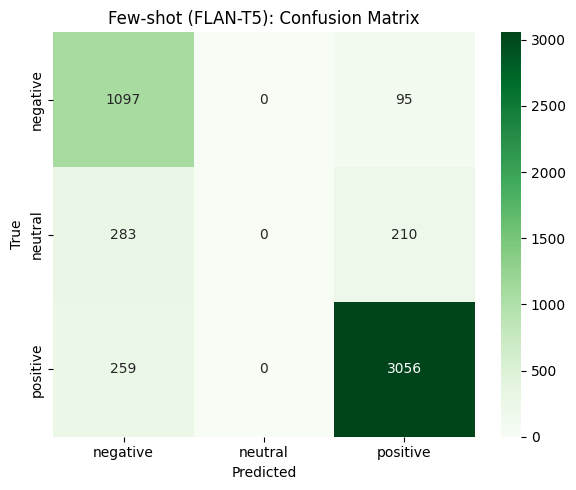

In [ ]:
# ============================================================
# FEW-SHOT CONFUSION MATRIX
# ============================================================

cm_fs = confusion_matrix(y_true_fs, y_pred_fs)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_fs, annot=True, fmt="d", cmap="Greens",
    xticklabels=id2label.values(),
    yticklabels=id2label.values(),
)
plt.title("Few-shot (FLAN-T5): Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# BOOTSTRAP CONFIDENCE INTERVALS
# ============================================================
# Resample the test set 1000 times to estimate uncertainty in
# each model's macro F1 score.

def bootstrap_macro_f1(y_true, y_pred, n_iterations=1000, ci_level=0.95):
    """Compute bootstrap confidence interval for macro F1."""
    rng = np.random.default_rng(seed=42)
    n_samples = len(y_true)
    scores = []
    for _ in range(n_iterations):
        idx = rng.integers(0, n_samples, size=n_samples)
        f1_resample = f1_score(
            np.asarray(y_true)[idx],
            np.asarray(y_pred)[idx],
            average='macro'
        )
        scores.append(f1_resample)
    scores = np.array(scores)
    lower = np.percentile(scores, (1 - ci_level) / 2 * 100)
    upper = np.percentile(scores, (1 + ci_level) / 2 * 100)
    return scores.mean(), lower, upper

# BERT-tiny predictions at tau = 0.65 from probs_all.
TAU = 0.65
y_pred_tau = np.empty(len(probs_all), dtype=int)
for i, p in enumerate(probs_all):
    if p[1] >= TAU:
        y_pred_tau[i] = 1
    else:
        y_pred_tau[i] = 0 if p[0] > p[2] else 2

# Apply bootstrap to each model.
print(f"{'Model':<28} {'Macro F1':>10} {'95% CI':>22}")
print("-" * 62)

mean, lo, hi = bootstrap_macro_f1(y_true, y_pred)
print(f"{'BERT-tiny (argmax)':<28} {mean:>10.4f} [{lo:.4f}, {hi:.4f}]")

mean, lo, hi = bootstrap_macro_f1(y_true, y_pred_tau)
print(f"{'BERT-tiny (tau=0.65)':<28} {mean:>10.4f} [{lo:.4f}, {hi:.4f}]")

mean, lo, hi = bootstrap_macro_f1(y_true_zs, y_pred_zs)
print(f"{'Zero-shot (BART-MNLI)':<28} {mean:>10.4f} [{lo:.4f}, {hi:.4f}]")

mean, lo, hi = bootstrap_macro_f1(y_true_fs, y_pred_fs)
print(f"{'Few-shot (FLAN-T5)':<28} {mean:>10.4f} [{lo:.4f}, {hi:.4f}]")

Model                          Macro F1                 95% CI
--------------------------------------------------------------
BERT-tiny (argmax)               0.7105 [0.6950, 0.7241]
BERT-tiny (tau=0.65)             0.7218 [0.7053, 0.7373]
Zero-shot (BART-MNLI)            0.7309 [0.7150, 0.7473]
Few-shot (FLAN-T5)               0.5634 [0.5561, 0.5706]


In [ ]:
# ============================================================
# MODEL COMPARISON SUMMARY
# ============================================================
# Final side by side comparison across all approaches. All metrics
# computed on the same 5000 example test set, so the numbers are
# directly comparable.

print("=" * 70)
print(f"{'MODEL COMPARISON':^70}")
print(f"{'(all approaches on the same 5,000-example test set)':^70}")
print("=" * 70)
print(f"{'Model':<28}{'Accuracy':>10}{'Weighted F1':>14}{'Macro F1':>12}")
print("-" * 70)
print(f"{'BERT-tiny (argmax)':<28}{accuracy:>10.4f}{f1_w:>14.4f}{f1_m:>12.4f}")
print(f"{'BERT-tiny (tau = ' + str(round(best_tau, 2)) + ')':<28}{best['accuracy']:>10.4f}{best['weighted_f1']:>14.4f}{best['macro_f1']:>12.4f}")
print(f"{'Zero-shot (BART-MNLI)':<28}{acc_zs:>10.4f}{f1_zs_w:>14.4f}{f1_zs_m:>12.4f}")
print(f"{'Few-shot (FLAN-T5)':<28}{acc_fs:>10.4f}{f1_fs_w:>14.4f}{f1_fs_m:>12.4f}")
print("=" * 70)

                           MODEL COMPARISON                           
         (all approaches on the same 5,000-example test set)          
Model                         Accuracy   Weighted F1    Macro F1
----------------------------------------------------------------------
BERT-tiny (argmax)              0.7998        0.8260      0.7104
BERT-tiny (tau = 0.65)          0.8334        0.8428      0.7217
Zero-shot (BART-MNLI)           0.8688        0.8676      0.7311
Few-shot (FLAN-T5)              0.8306        0.7917      0.5635


In [ ]:
# ============================================================
# END OF TASK 2
# ============================================================

print("\n" + "=" * 60)
print("END OF TASK 2")
print("=" * 60)


END OF TASK 2
